## some exploratory data analysis

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all three prices files
file_paths = [
    r"C:/Users/cadem/Prosperity4/data/ROUND_1/ROUND1/prices_round_1_day_-2.csv",
    r"C:/Users/cadem/Prosperity4/data/ROUND_1/ROUND1/prices_round_1_day_-1.csv",
    r"C:/Users/cadem/Prosperity4/data/ROUND_1/ROUND1/prices_round_1_day_0.csv",
]

dfs = [pd.read_csv(fp, sep=';') for fp in file_paths]
prices = pd.concat(dfs, ignore_index=True)

# Keep only the two products you want
prices = prices[prices['product'].isin([
    'INTARIAN_PEPPER_ROOT',
    'ASH_COATED_OSMIUM'
])].copy()

# Sort across files
prices = prices.sort_values(['product', 'day', 'timestamp']).reset_index(drop=True)

# Forward fill only these four columns within each product
cols_to_fill = [
    'bid_price_1',
    'bid_volume_1',
    'ask_price_1',
    'ask_volume_1'
]

prices[cols_to_fill] = prices.groupby('product')[cols_to_fill].ffill()

# Build a continuous time axis so the three days plot cleanly
timestamp_step = prices['timestamp'].dropna().sort_values().diff().mode()
timestamp_step = int(timestamp_step.iloc[0]) if not timestamp_step.empty else 100
day_span = int(prices['timestamp'].max() + timestamp_step)

min_day = int(prices['day'].min())
prices['global_timestamp'] = (prices['day'] - min_day) * day_span + prices['timestamp']

# Split into separate dataframes
print(prices.head())

prices['mid_price'] = (prices['bid_price_1'] + prices['ask_price_1']) / 2

pepper_prices = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy().reset_index(drop=True)
osmium_prices = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy().reset_index(drop=True)

print(pepper_prices.head())
print(osmium_prices.head())

   day  timestamp            product  bid_price_1  bid_volume_1  bid_price_2  \
0   -2          0  ASH_COATED_OSMIUM          NaN           NaN          NaN   
1   -2        100  ASH_COATED_OSMIUM       9992.0          15.0          NaN   
2   -2        200  ASH_COATED_OSMIUM       9992.0          15.0       9989.0   
3   -2        300  ASH_COATED_OSMIUM       9992.0          13.0       9989.0   
4   -2        400  ASH_COATED_OSMIUM       9992.0          15.0          NaN   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0           NaN          NaN           NaN      10010.0          25.0   
1           NaN          NaN           NaN      10008.0          15.0   
2          30.0          NaN           NaN      10008.0          15.0   
3          26.0          NaN           NaN      10008.0          13.0   
4           NaN          NaN           NaN      10008.0          15.0   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
0         

## mid price

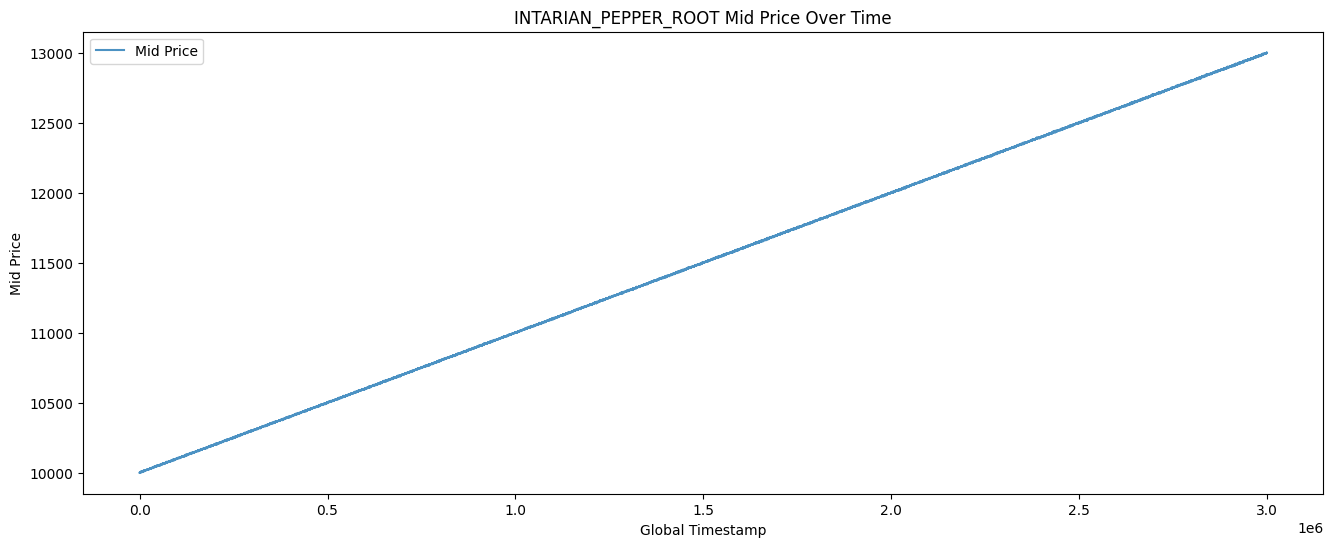

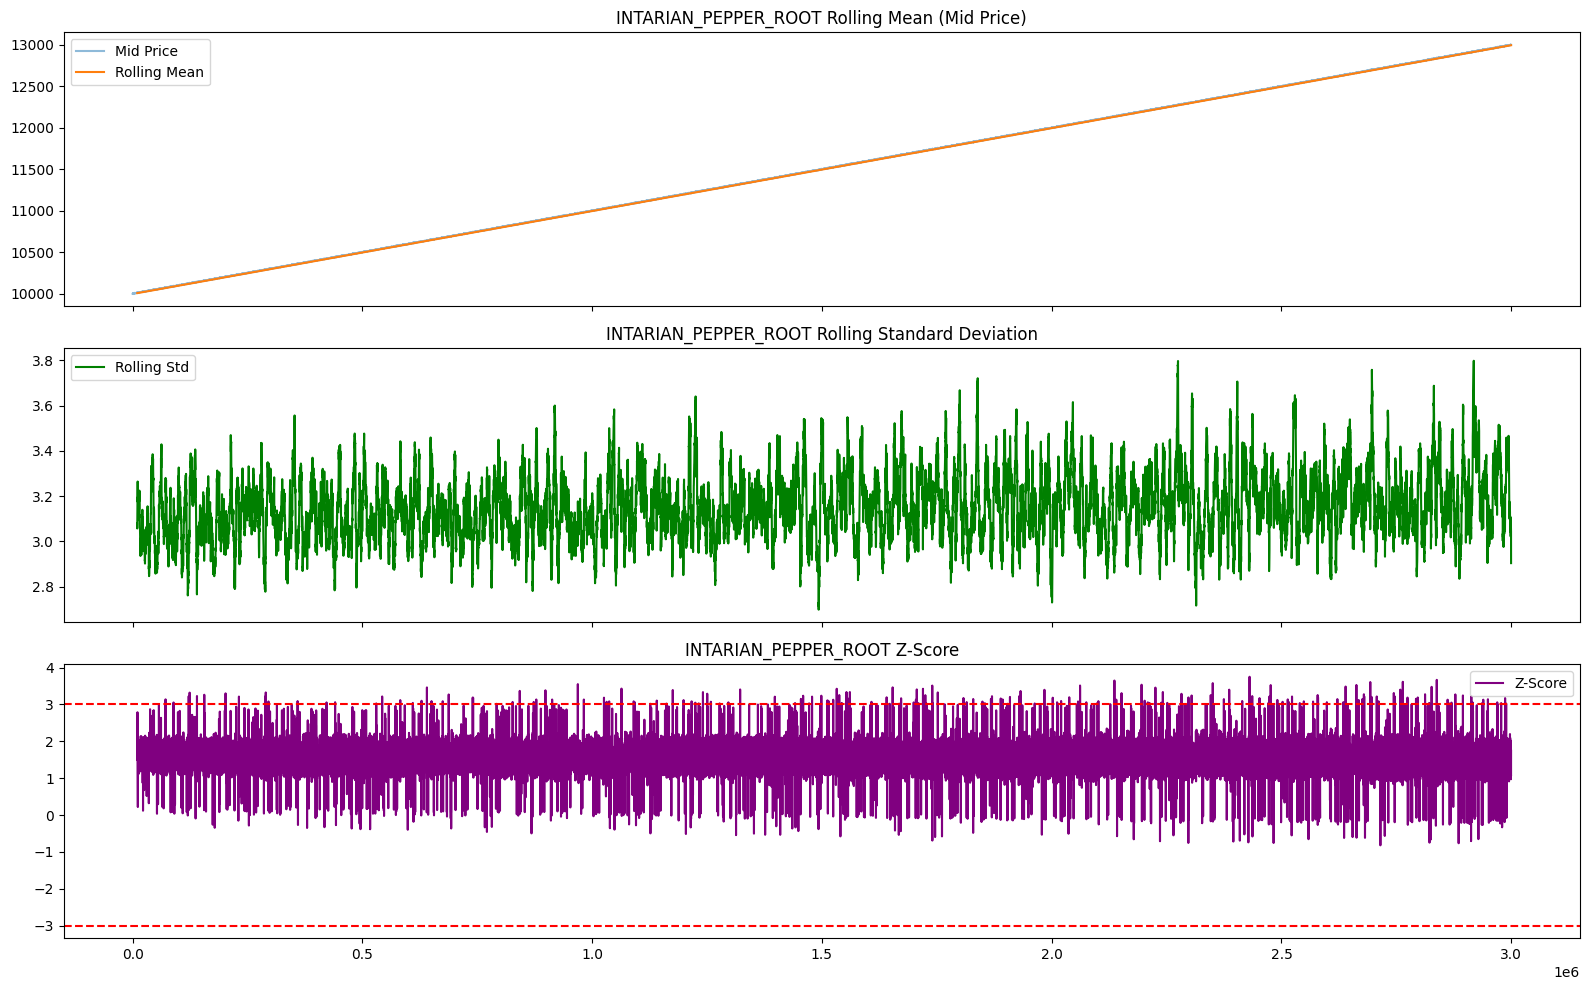

In [51]:
# Mid price over time
plt.figure(figsize=(16, 6))
plt.plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('INTARIAN_PEPPER_ROOT Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

# Rolling stats
WINDOW = 100

pepper_prices['rolling_mean'] = pepper_prices['mid_price'].rolling(WINDOW).mean()
pepper_prices['rolling_std'] = pepper_prices['mid_price'].rolling(WINDOW).std()
pepper_prices['z_score'] = (
    (pepper_prices['mid_price'] - pepper_prices['rolling_mean']) 
    / pepper_prices['rolling_std']
)

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axs[0].plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(pepper_prices['global_timestamp'], pepper_prices['rolling_mean'], label='Rolling Mean')
axs[0].set_title('INTARIAN_PEPPER_ROOT Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(pepper_prices['global_timestamp'], pepper_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('INTARIAN_PEPPER_ROOT Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(pepper_prices['global_timestamp'], pepper_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='r', linestyle='--')
axs[2].axhline(-3, color='r', linestyle='--')
axs[2].set_title('INTARIAN_PEPPER_ROOT Z-Score')
axs[2].legend()

plt.tight_layout()
plt.show()

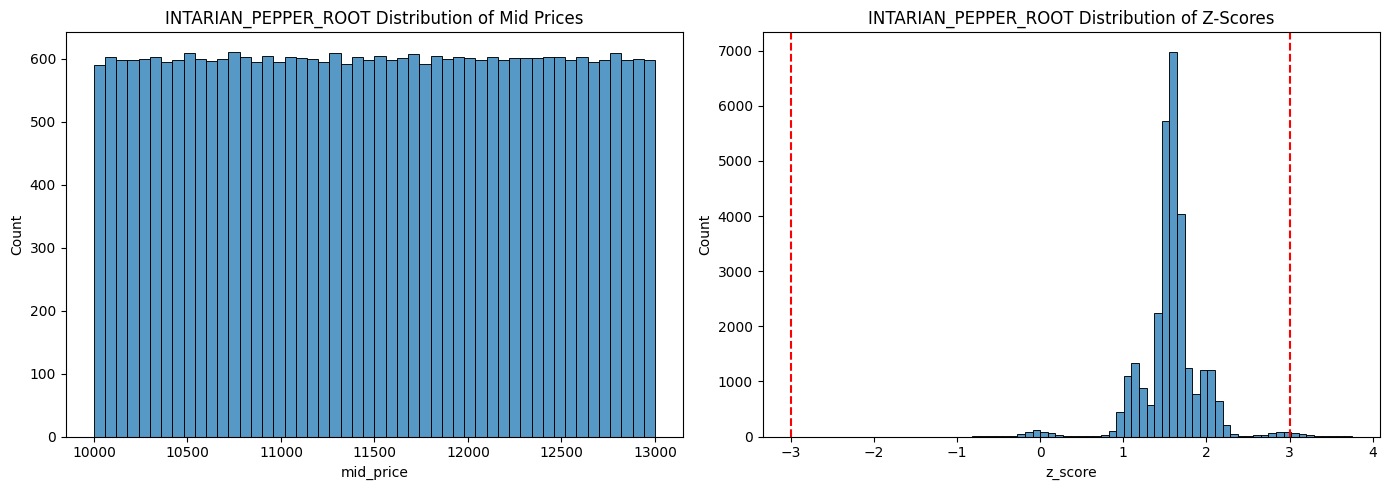

In [52]:
# Distributions
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(pepper_prices['mid_price'], bins=50, ax=axs[0])
axs[0].set_title("INTARIAN_PEPPER_ROOT Distribution of Mid Prices")

sns.histplot(pepper_prices['z_score'].dropna(), bins=50, ax=axs[1])
axs[1].axvline(3, color='r', linestyle='--')
axs[1].axvline(-3, color='r', linestyle='--')
axs[1].set_title("INTARIAN_PEPPER_ROOT Distribution of Z-Scores")

plt.tight_layout()
plt.show()

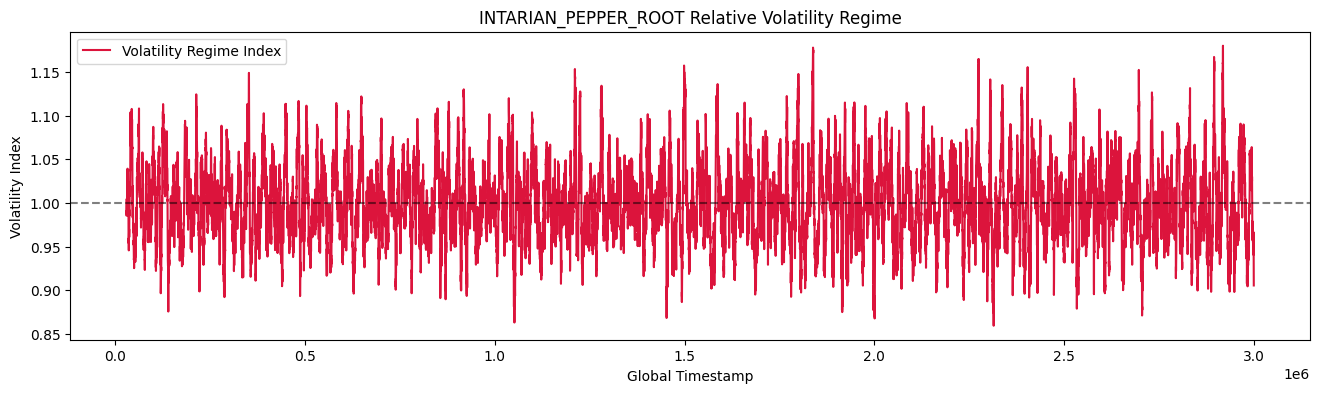

In [53]:
# Volatility regime
VOL_WINDOW = 200
pepper_prices['volatility_regime'] = (
    pepper_prices['rolling_std'] 
    / pepper_prices['rolling_std'].rolling(VOL_WINDOW).mean()
)

plt.figure(figsize=(16, 4))
plt.plot(pepper_prices['global_timestamp'], pepper_prices['volatility_regime'],
         label='Volatility Regime Index', color='crimson')
plt.axhline(1, linestyle='--', color='black', alpha=0.5)
plt.title('INTARIAN_PEPPER_ROOT Relative Volatility Regime')
plt.xlabel('Global Timestamp')
plt.ylabel('Volatility Index')
plt.legend()
plt.show()

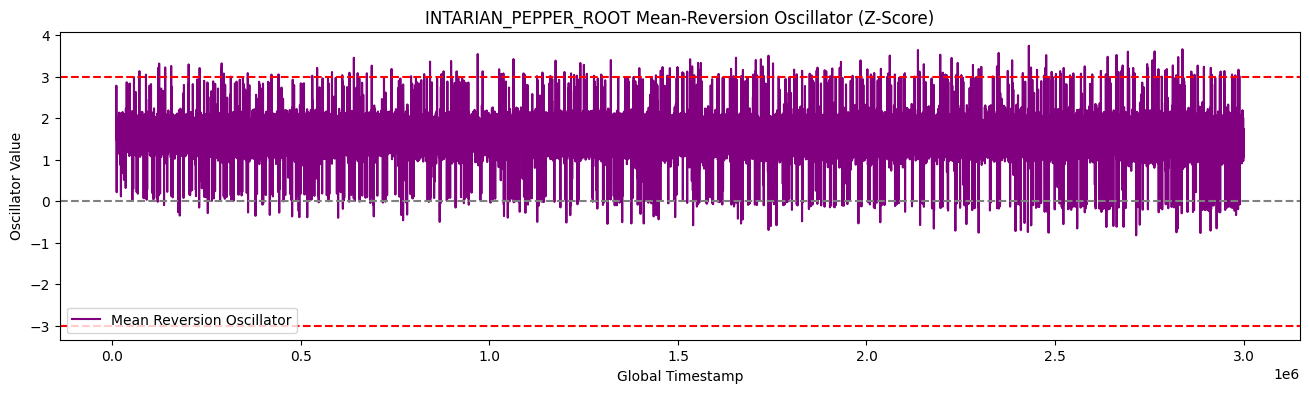

In [54]:
# Mean-reversion oscillator
pepper_prices['oscillator'] = (
    (pepper_prices['mid_price'] - pepper_prices['rolling_mean']) 
    / pepper_prices['rolling_std']
)

plt.figure(figsize=(16, 4))
plt.plot(pepper_prices['global_timestamp'], pepper_prices['oscillator'],
         label='Mean Reversion Oscillator', color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title('INTARIAN_PEPPER_ROOT Mean-Reversion Oscillator (Z-Score)')
plt.xlabel('Global Timestamp')
plt.ylabel('Oscillator Value')
plt.legend()
plt.show()

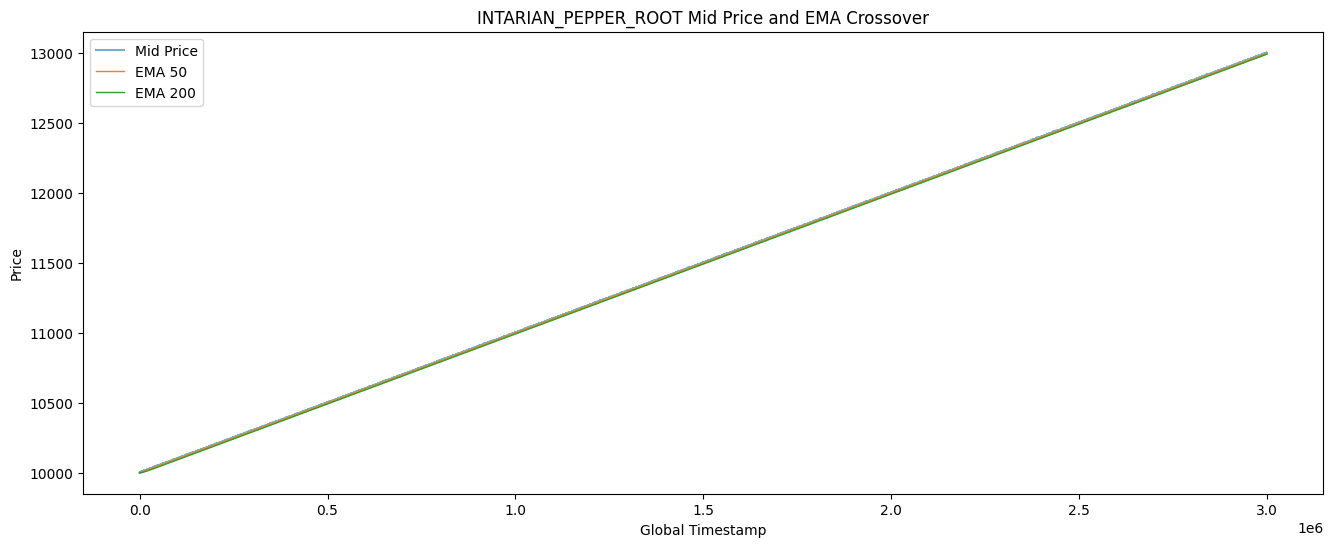

In [55]:
# EMA crossover
SHORT_WINDOW = 50
LONG_WINDOW = 200

pepper_prices['ema_short'] = pepper_prices['mid_price'].ewm(span=SHORT_WINDOW, adjust=False).mean()
pepper_prices['ema_long'] = pepper_prices['mid_price'].ewm(span=LONG_WINDOW, adjust=False).mean()
pepper_prices['ema_diff'] = pepper_prices['ema_short'] - pepper_prices['ema_long']

plt.figure(figsize=(16, 6))
plt.plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(pepper_prices['global_timestamp'], pepper_prices['ema_short'], label=f'EMA {SHORT_WINDOW}', linewidth=1)
plt.plot(pepper_prices['global_timestamp'], pepper_prices['ema_long'], label=f'EMA {LONG_WINDOW}', linewidth=1)
plt.title('INTARIAN_PEPPER_ROOT Mid Price and EMA Crossover')
plt.xlabel('Global Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

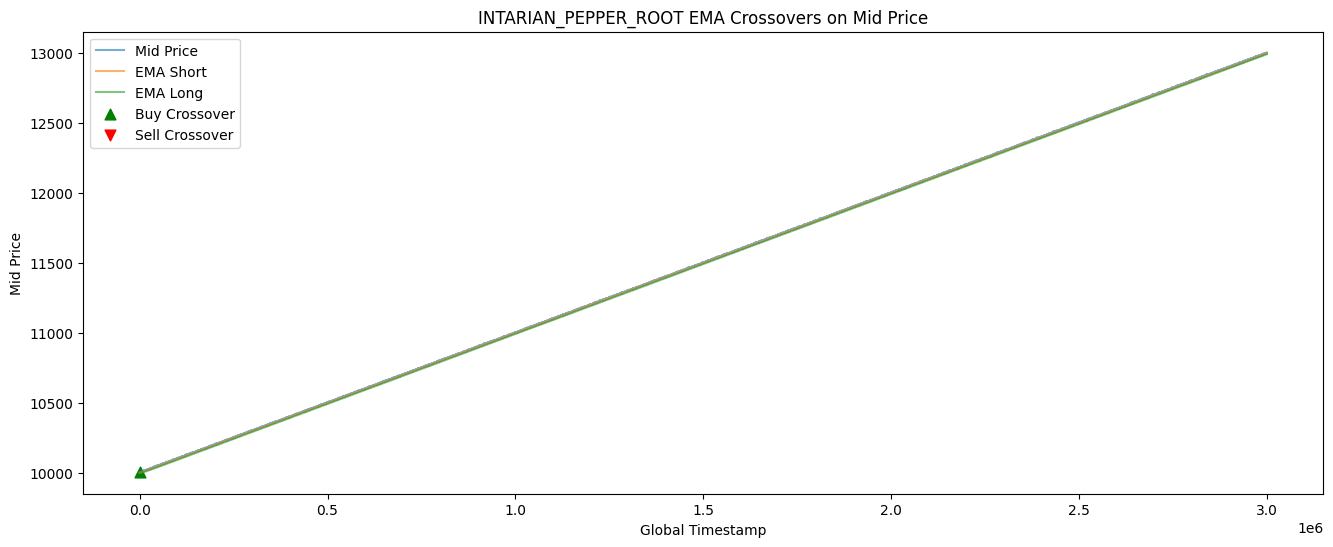

In [56]:
# Detect crossover points
pepper_prices['signal'] = 0
pepper_prices.loc[pepper_prices['ema_diff'] > 0, 'signal'] = 1
pepper_prices.loc[pepper_prices['ema_diff'] < 0, 'signal'] = -1

pepper_prices['signal_shift'] = pepper_prices['signal'].shift(1)
pepper_prices['crossover'] = pepper_prices['signal'] != pepper_prices['signal_shift']

crossovers = pepper_prices[(pepper_prices['crossover']) & (pepper_prices['signal'] != 0)]

buy_cross = crossovers[crossovers['signal'] == 1]
sell_cross = crossovers[crossovers['signal'] == -1]

plt.figure(figsize=(16, 6))
plt.plot(pepper_prices['global_timestamp'], pepper_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(pepper_prices['global_timestamp'], pepper_prices['ema_short'], label='EMA Short', alpha=0.6)
plt.plot(pepper_prices['global_timestamp'], pepper_prices['ema_long'], label='EMA Long', alpha=0.6)
plt.scatter(buy_cross['global_timestamp'], buy_cross['mid_price'], color='green', label='Buy Crossover', marker='^', s=60)
plt.scatter(sell_cross['global_timestamp'], sell_cross['mid_price'], color='red', label='Sell Crossover', marker='v', s=60)
plt.title('INTARIAN_PEPPER_ROOT EMA Crossovers on Mid Price')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

## Ash Coated Osmium

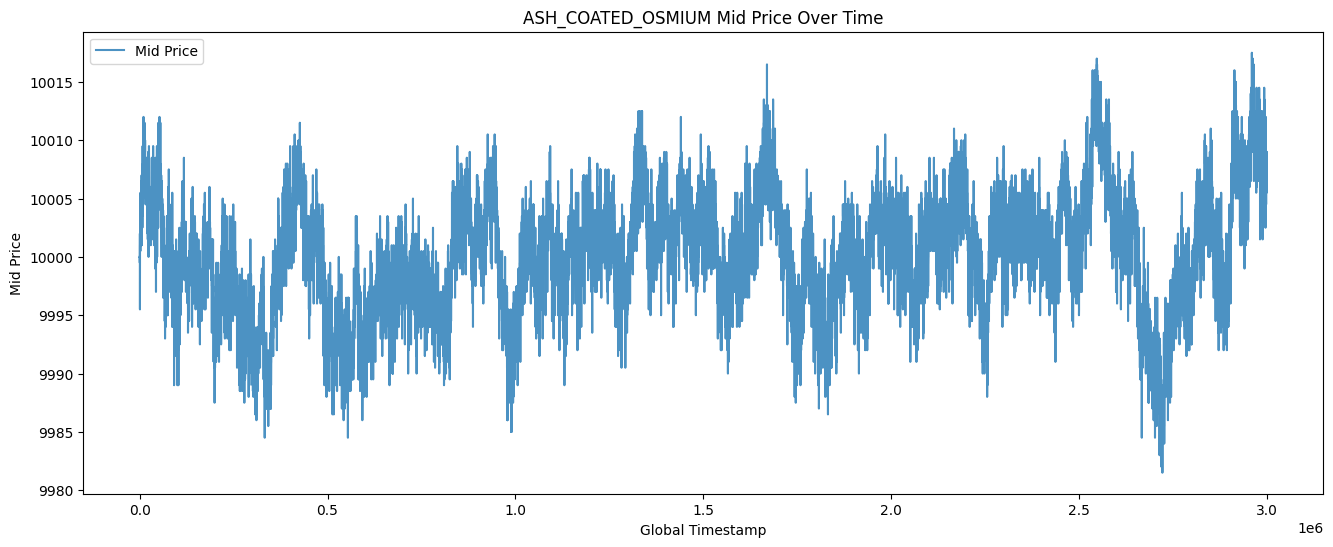

In [57]:
# Mid price over time
plt.figure(figsize=(16, 6))
plt.plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], label='Mid Price', alpha=0.8)
plt.title('ASH_COATED_OSMIUM Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()

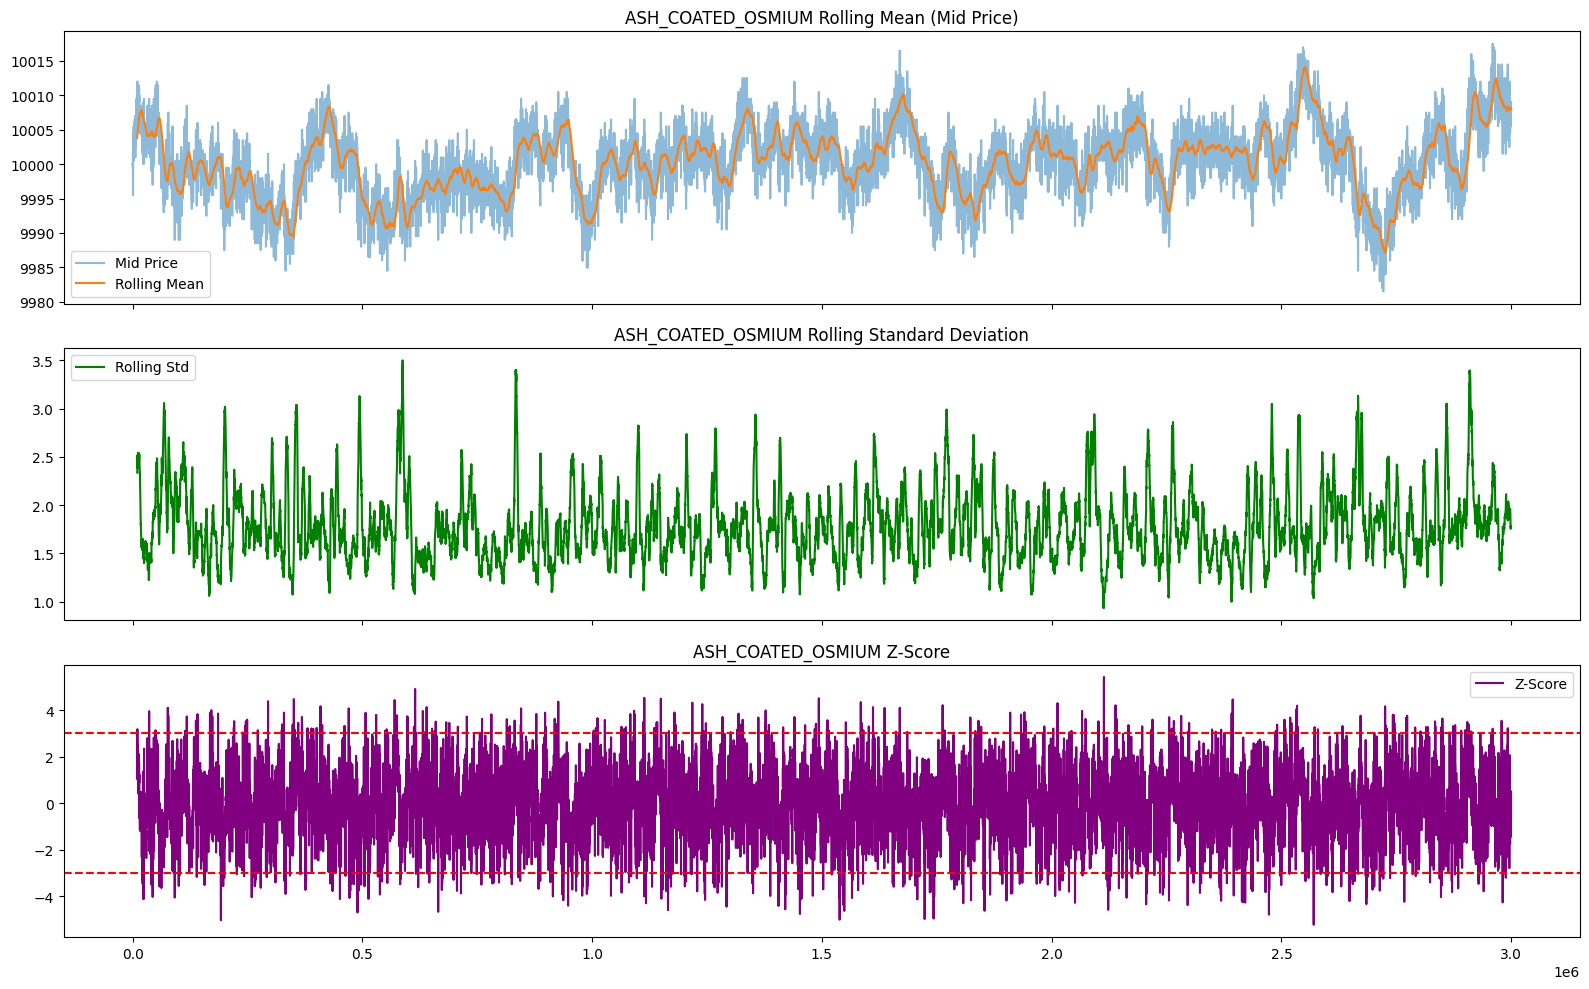

In [58]:
# Rolling stats
WINDOW = 100

osmium_prices['rolling_mean'] = osmium_prices['mid_price'].rolling(WINDOW).mean()
osmium_prices['rolling_std'] = osmium_prices['mid_price'].rolling(WINDOW).std()
osmium_prices['z_score'] = (
    (osmium_prices['mid_price'] - osmium_prices['rolling_mean']) 
    / osmium_prices['rolling_std']
)

fig, axs = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axs[0].plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], label='Mid Price', alpha=0.5)
axs[0].plot(osmium_prices['global_timestamp'], osmium_prices['rolling_mean'], label='Rolling Mean')
axs[0].set_title('ASH_COATED_OSMIUM Rolling Mean (Mid Price)')
axs[0].legend()

axs[1].plot(osmium_prices['global_timestamp'], osmium_prices['rolling_std'], label='Rolling Std', color='green')
axs[1].set_title('ASH_COATED_OSMIUM Rolling Standard Deviation')
axs[1].legend()

axs[2].plot(osmium_prices['global_timestamp'], osmium_prices['z_score'], label='Z-Score', color='purple')
axs[2].axhline(3, color='r', linestyle='--')
axs[2].axhline(-3, color='r', linestyle='--')
axs[2].set_title('ASH_COATED_OSMIUM Z-Score')
axs[2].legend()

plt.tight_layout()
plt.show()

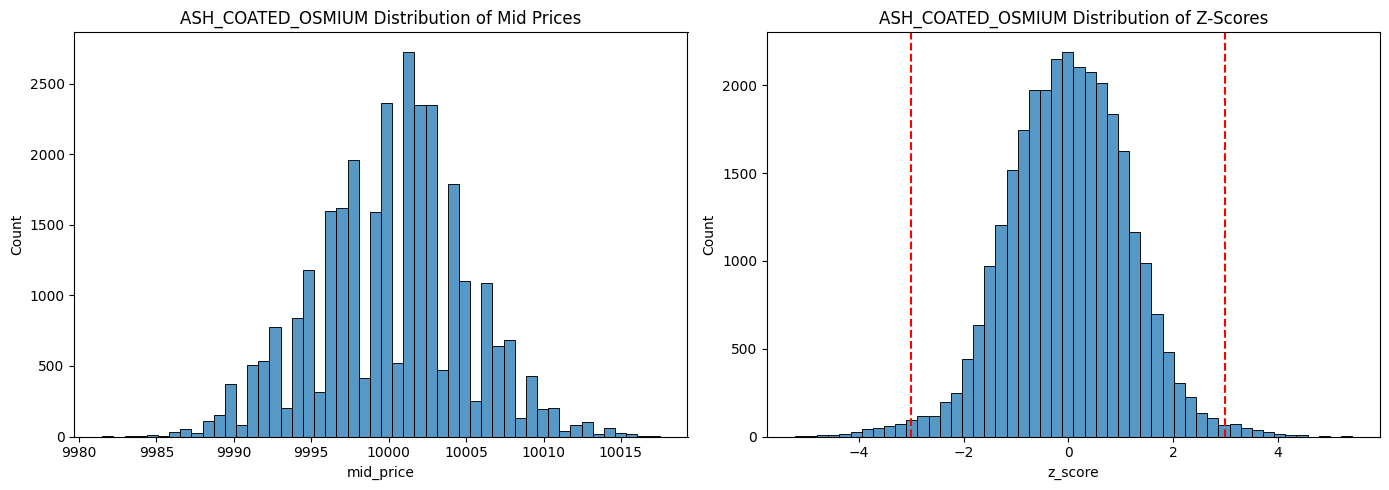

In [59]:
# Distributions
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(osmium_prices['mid_price'], bins=50, ax=axs[0])
axs[0].set_title("ASH_COATED_OSMIUM Distribution of Mid Prices")

sns.histplot(osmium_prices['z_score'].dropna(), bins=50, ax=axs[1])
axs[1].axvline(3, color='r', linestyle='--')
axs[1].axvline(-3, color='r', linestyle='--')
axs[1].set_title("ASH_COATED_OSMIUM Distribution of Z-Scores")

plt.tight_layout()
plt.show()

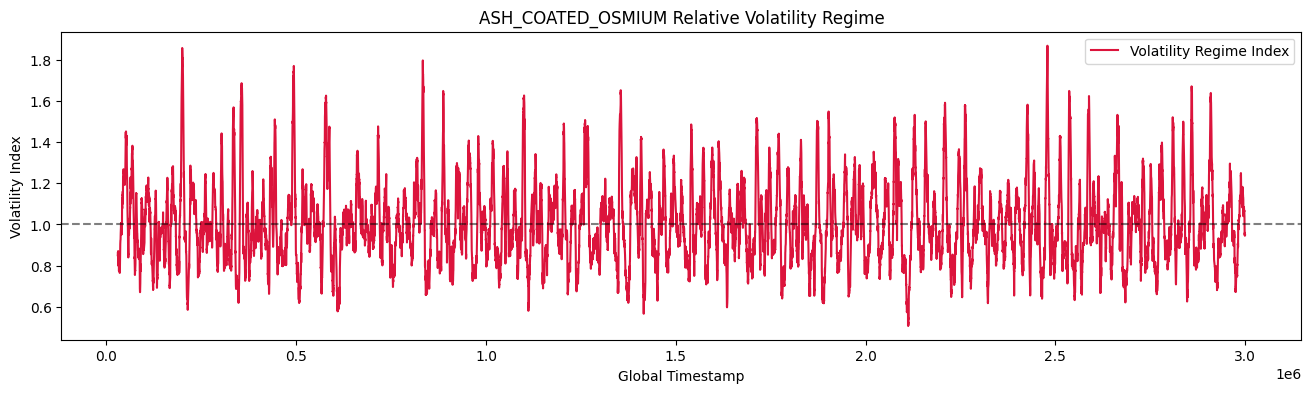

In [60]:
# Volatility regime
VOL_WINDOW = 200
osmium_prices['volatility_regime'] = (
    osmium_prices['rolling_std'] 
    / osmium_prices['rolling_std'].rolling(VOL_WINDOW).mean()
)

plt.figure(figsize=(16, 4))
plt.plot(osmium_prices['global_timestamp'], osmium_prices['volatility_regime'],
         label='Volatility Regime Index', color='crimson')
plt.axhline(1, linestyle='--', color='black', alpha=0.5)
plt.title('ASH_COATED_OSMIUM Relative Volatility Regime')
plt.xlabel('Global Timestamp')
plt.ylabel('Volatility Index')
plt.legend()
plt.show()

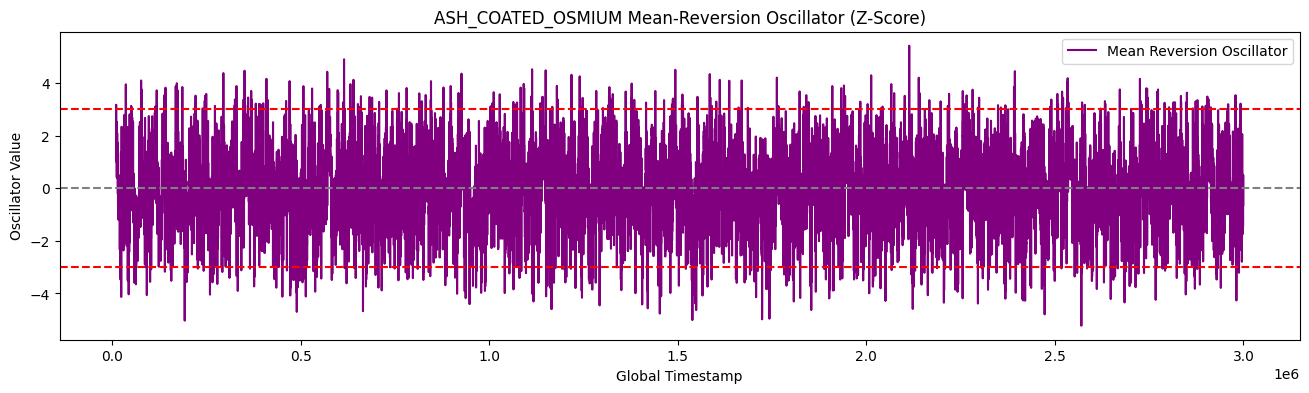

In [61]:
# Mean-reversion oscillator
osmium_prices['oscillator'] = (
    (osmium_prices['mid_price'] - osmium_prices['rolling_mean']) 
    / osmium_prices['rolling_std']
)

plt.figure(figsize=(16, 4))
plt.plot(osmium_prices['global_timestamp'], osmium_prices['oscillator'],
         label='Mean Reversion Oscillator', color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title('ASH_COATED_OSMIUM Mean-Reversion Oscillator (Z-Score)')
plt.xlabel('Global Timestamp')
plt.ylabel('Oscillator Value')
plt.legend()
plt.show()

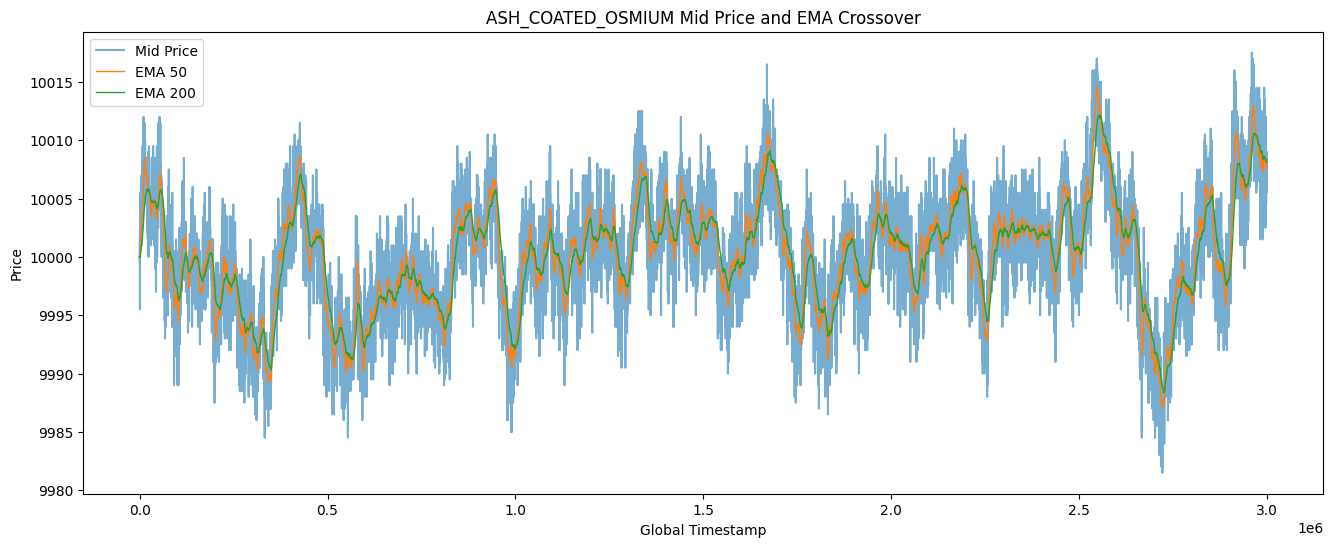

In [62]:
# EMA crossover
SHORT_WINDOW = 50
LONG_WINDOW = 200

osmium_prices['ema_short'] = osmium_prices['mid_price'].ewm(span=SHORT_WINDOW, adjust=False).mean()
osmium_prices['ema_long'] = osmium_prices['mid_price'].ewm(span=LONG_WINDOW, adjust=False).mean()
osmium_prices['ema_diff'] = osmium_prices['ema_short'] - osmium_prices['ema_long']

plt.figure(figsize=(16, 6))
plt.plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(osmium_prices['global_timestamp'], osmium_prices['ema_short'], label=f'EMA {SHORT_WINDOW}', linewidth=1)
plt.plot(osmium_prices['global_timestamp'], osmium_prices['ema_long'], label=f'EMA {LONG_WINDOW}', linewidth=1)
plt.title('ASH_COATED_OSMIUM Mid Price and EMA Crossover')
plt.xlabel('Global Timestamp')
plt.ylabel('Price')
plt.legend()
plt.show()

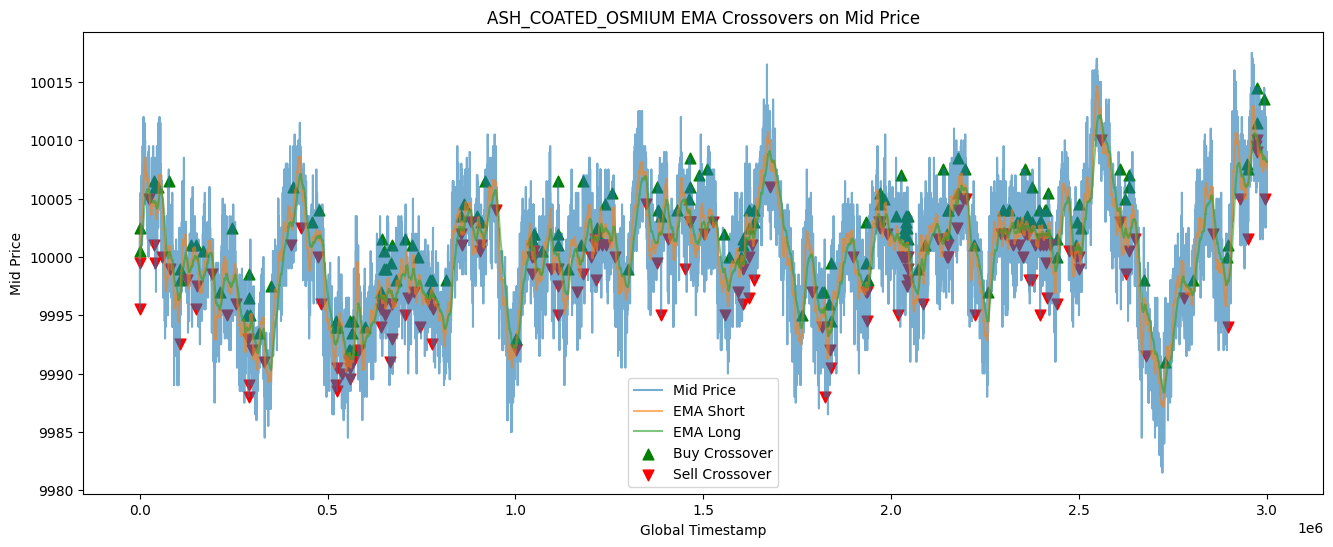

In [63]:
# Detect crossover points
osmium_prices['signal'] = 0
osmium_prices.loc[osmium_prices['ema_diff'] > 0, 'signal'] = 1
osmium_prices.loc[osmium_prices['ema_diff'] < 0, 'signal'] = -1

osmium_prices['signal_shift'] = osmium_prices['signal'].shift(1)
osmium_prices['crossover'] = osmium_prices['signal'] != osmium_prices['signal_shift']

crossovers = osmium_prices[(osmium_prices['crossover']) & (osmium_prices['signal'] != 0)]

buy_cross = crossovers[crossovers['signal'] == 1]
sell_cross = crossovers[crossovers['signal'] == -1]

plt.figure(figsize=(16, 6))
plt.plot(osmium_prices['global_timestamp'], osmium_prices['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(osmium_prices['global_timestamp'], osmium_prices['ema_short'], label='EMA Short', alpha=0.6)
plt.plot(osmium_prices['global_timestamp'], osmium_prices['ema_long'], label='EMA Long', alpha=0.6)
plt.scatter(buy_cross['global_timestamp'], buy_cross['mid_price'], color='green', label='Buy Crossover', marker='^', s=60)
plt.scatter(sell_cross['global_timestamp'], sell_cross['mid_price'], color='red', label='Sell Crossover', marker='v', s=60)
plt.title('ASH_COATED_OSMIUM EMA Crossovers on Mid Price')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.legend()
plt.show()